In [2]:
import numpy as np
import pandas as pd
import glob
from numba import guvectorize
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import os
from datetime import datetime, timezone
import re
import json
import awkward as ak
import pygama 


from dbetto import Props
from legendmeta import LegendMetadata
from lgdo import lh5
import lgdo
from dspeed.vis.waveform_browser import WaveformBrowser
from pygama.pargen.dsp_optimize import run_one_dsp
import lgdo.types as lgdo_types
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import matplotlib.patches as mpatches
from collections import defaultdict
from pathlib import Path

import itertools
from tqdm import tqdm
import time

# Starting

In [3]:
data_path = "/global/cfs/cdirs/m2676/data/lngs/l200/public/prodenv/prod-blind/ref/latest"
config = Props.read_from(os.path.join(data_path, "config.json"), subst_pathvar=True)["setups"]["l200"]["paths"]
lmeta  = LegendMetadata(config["metadata"])
chmap = ak.Array(lmeta.channelmap(lmeta.dataprod.runinfo.p03.r000.phy.start_key).group("system").geds.values())

In [4]:
detector = "B00035B"
chn = chmap.daq.rawid[chmap.name == detector][0]

In [5]:
pet_files = sorted(glob.glob(f"{config['tier_pet']}/phy/l200-p0[346789]-*-phy-tier_pet.lh5"))

# Load in event data. We will get:
# - coincident tells us if an event was a pulser, ged, or spm event
# - geds contains all info related to the geds system such as quality uts, PSD, detector statuses, and energy
# - trigger contains forced triggers and the timestamps for every event
start = time.time()
data_init = lh5.read_as("/evt", pet_files, field_mask=["coincident", "geds", "trigger"], library="ak")
print("Took", time.time() - start, "s to read")

Took 75.09518146514893 s to read


In [44]:
data = data_init[
    ~data_init.trigger.is_forced &
    ~data_init.coincident.puls &
    ~data_init.coincident.muon_offline &
    data_init.coincident.geds &
    #(data_init.geds.quality.is_bb_like) &
    ak.all(data_init.geds.quality.is_good_channel, axis=-1)
]

In [45]:

# in questo modo io sto lavorando soltanto con un detector
mydet = (ak.num(data.geds.rawid, axis=1) == 1) & (data.geds.rawid[:, 0] == chn)

In [46]:
events = data[mydet]
ene = events[ak.any((events.geds.rawid == chn), axis=1)].geds.energy

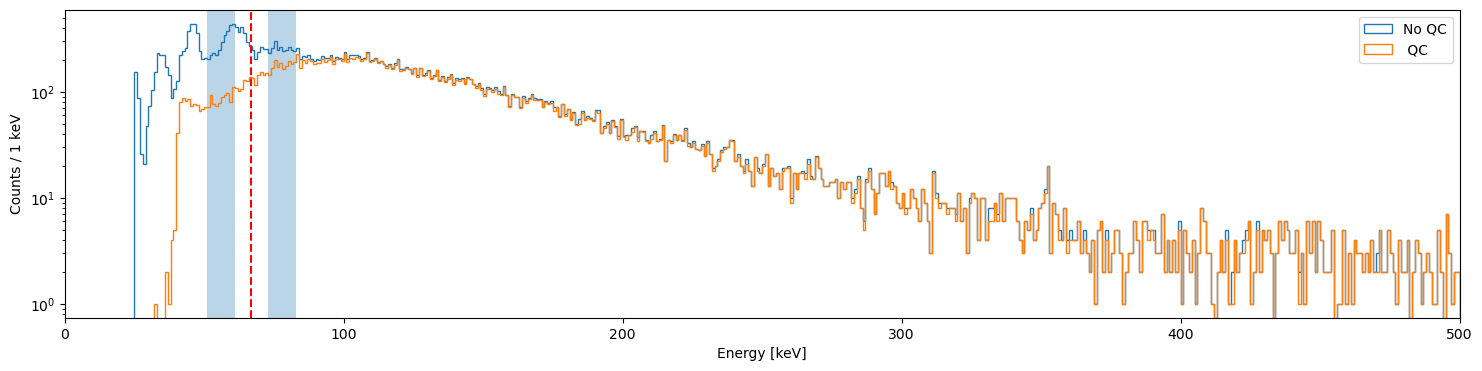

In [47]:
_, ax = plt.subplots(figsize = (18, 4))
emin = 0
emax = 500
bins = emax - emin
ax.hist(ene, bins = bins, range = (emin, emax), histtype = 'step', label = "No QC")
ax.hist(ene[(events.geds.quality.is_bb_like)], bins = bins, range = (emin, emax), histtype = 'step', label = " QC")
ax.set_ylabel("Counts / 1 keV")
ax.set_xlabel("Energy [keV]")
ax.set_xlim(emin, emax)
ax.axvline(x=66.7, ls="dashed", color ="red")
ax.axvspan(67+6, 67+16, alpha=0.3)
ax.axvspan(67-16, 67-6, alpha=0.3)
ax.set_yscale('log')
ax.legend()
plt.show()